# 6.1. EEG/MEG Connectivity Analysis

**Learning Objectives:**
- Understand different types of brain connectivity measures
- Learn to compute functional connectivity from EEG/MEG data
- Apply connectivity metrics in sensor and source space
- Analyze frequency-specific connectivity patterns
- Visualize connectivity networks and graphs
- Compare connectivity across experimental conditions

**Key Concepts:**
- **Functional Connectivity**: Statistical dependencies between brain regions
- **Coherence**: Frequency-domain correlation between signals
- **Phase Locking Value (PLV)**: Phase synchronization measure
- **Imaginary Coherence**: Reduces volume conduction artifacts
- **Directed Connectivity**: Measures of information flow (e.g., Granger causality)
- **Graph Theory**: Network-based analysis of brain connectivity

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import mne
from mne.datasets import sample
from mne.minimum_norm import make_inverse_operator, apply_inverse_epochs
from mne_connectivity import spectral_connectivity_epochs, envelope_correlation

import pandas as pd
from scipy import stats
import networkx as nx

import warnings
warnings.filterwarnings('ignore')

In [2]:
sns.set_context("notebook", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

## 1. Understanding Connectivity Analysis

### What is Brain Connectivity?

Brain connectivity refers to patterns of links or relationships between different brain regions. There are three main types:

1. **Structural Connectivity**: Physical connections (axons, white matter tracts)
   - Measured with: DTI, tractography
   - Relatively stable over time

2. **Functional Connectivity**: Statistical dependencies between regions
   - Measured with: EEG, MEG, fMRI
   - Changes with cognitive state
   - **This is what we focus on in this tutorial**

3. **Effective Connectivity**: Causal influences between regions
   - Measured with: Granger causality, DCM
   - Directional relationships

### Connectivity Metrics Overview

| Metric | Type | Best For | Limitations |
|--------|------|----------|-------------|
| **Coherence** | Magnitude & phase | Frequency-specific coupling | Sensitive to volume conduction |
| **Imaginary Coherence** | Phase only | Reducing volume conduction | Misses zero-lag interactions |
| **Phase Locking Value (PLV)** | Phase sync | Phase synchronization | Sensitive to volume conduction |
| **Envelope Correlation** | Amplitude | Slow amplitude coupling | Requires source space |
| **Granger Causality** | Directed | Information flow | Requires stationarity |

### The Volume Conduction Problem

**Challenge**: In EEG/MEG, the same source can be picked up by multiple sensors due to:
- Electromagnetic field spread
- Instantaneous propagation

**Solutions**:
1. Use **source space** instead of sensor space
2. Use **imaginary coherence** (only non-zero lag connections)
3. Apply **orthogonalization** methods
4. Use **envelope correlation** (slow amplitude coupling)

## 2. Load Sample Data & Preprocessing

In [3]:
repo_root = Path("./").resolve().parents[1]
target_dir = repo_root / "datasets" / "meg_sample"
target_dir.mkdir(parents=True, exist_ok=True)

data_path = sample.data_path(path=str(target_dir), download=True)
subjects_dir = data_path / 'subjects'

meg_file = data_path / "MEG" / "sample" / "sample_audvis_raw.fif"
events_fname = data_path / 'MEG' / 'sample' / 'sample_audvis_raw-eve.fif'

raw = mne.io.read_raw_fif(meg_file, preload=True)
events = mne.read_events(events_fname)

print(f"Loaded raw data with {len(raw.ch_names)} channels")
print(f"Found {len(events)} events")

Opening raw data file /Users/yibeisita/Documents/neuro-ai-playground/datasets/meg_sample/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
Loaded raw data with 376 channels
Found 320 events


In [4]:
# Basic preprocessing
raw.filter(l_freq=1.0, h_freq=40.0, n_jobs=1)
raw.notch_filter(freqs=60.0, n_jobs=1)

# Pick MEG channels only
raw.pick_types(meg=True, eeg=False, stim=False, eog=False)

print(f"Filtered data, {len(raw.ch_names)} channels remaining")

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1983 samples (3.302 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edg

In [5]:
# Create epochs
event_id = {'auditory/left': 1, 'auditory/right': 2, 'visual/left': 3, 'visual/right': 4}
tmin, tmax = -0.2, 0.5

epochs = mne.Epochs(
    raw, events, event_id, tmin, tmax,
    baseline=(None, 0), preload=True,
    reject=dict(mag=4e-12, grad=4000e-13)
)

print(f"Created {len(epochs)} epochs")
print(f"Epochs shape: {epochs.get_data().shape}")

Not setting metadata
289 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 3)
3 projection items activated
Using data from preloaded Raw for 289 events and 421 original time points ...
    Rejecting  epoch based on MAG : ['MEG 1711']
    Rejecting  epoch based on MAG : ['MEG 1711']
2 bad epochs dropped
Created 287 epochs
Epochs shape: (287, 305, 421)


In [6]:
# Separate conditions
epochs_auditory = epochs['auditory']
epochs_visual = epochs['visual']

print(f"Auditory epochs: {len(epochs_auditory)}")
print(f"Visual epochs: {len(epochs_visual)}")

Auditory epochs: 143
Visual epochs: 144


## 3. Sensor-Space Connectivity

### 3.1. Coherence Analysis

**Coherence** measures the consistency of phase and amplitude relationships between two signals at each frequency.

**Mathematical Definition:**
$$
Coh_{xy}(f) = \frac{|P_{xy}(f)|^2}{P_{xx}(f) P_{yy}(f)}
$$

Where:
- $P_{xy}(f)$ is the cross-spectral density
- $P_{xx}(f)$, $P_{yy}(f)$ are auto-spectral densities
- Range: [0, 1] (0 = no coupling, 1 = perfect coupling)

In [7]:
# Select a subset of sensors for visualization
# Pick 10 sensors from different regions
from itertools import combinations

sensor_indices = [0, 20, 40, 60, 80, 100, 120, 140, 160, 180]
selected_ch_names = [epochs.ch_names[i] for i in sensor_indices]

print(f"Selected sensors: {selected_ch_names}")
print(f"Number of sensors: {len(sensor_indices)}")

# Separate conditions (keep as variables for later use)
epochs_auditory = epochs['auditory']
epochs_visual = epochs['visual']

print(f"\nAuditory epochs: {len(epochs_auditory)}")
print(f"Visual epochs: {len(epochs_visual)}")

Selected sensors: ['MEG 0113', 'MEG 0231', 'MEG 0423', 'MEG 0613', 'MEG 0731', 'MEG 0943', 'MEG 1133', 'MEG 1311', 'MEG 1443', 'MEG 1632']
Number of sensors: 10

Auditory epochs: 143
Visual epochs: 144


In [8]:
# Compute coherence for auditory condition using indices approach
# This avoids the data corruption issue with .pick_channels()
fmin, fmax = 8., 30.

# Create all pairs for all-to-all connectivity
pairs = list(combinations(range(len(sensor_indices)), 2))
indices = (
    np.array([sensor_indices[i] for i, j in pairs]),
    np.array([sensor_indices[j] for i, j in pairs])
)

print(f"Computing {len(pairs)} connections between {len(sensor_indices)} sensors")
print(f"Frequency range: {fmin}-{fmax} Hz")

con_aud = spectral_connectivity_epochs(
    epochs_auditory,
    method='coh',
    mode='multitaper',
    sfreq=epochs.info['sfreq'],
    fmin=fmin,
    fmax=fmax,
    faverage=True,
    indices=indices,
    n_jobs=1
)

print(f"Computed coherence for auditory condition")
print(f"Connectivity data shape: {con_aud.get_data().shape}")

Computing 45 connections between 10 sensors
Frequency range: 8.0-30.0 Hz
Adding metadata with 3 columns
Connectivity computation...
    computing connectivity for 45 connections
    using t=-0.200s..0.499s for estimation (421 points)
    frequencies: 8.6Hz..30.0Hz (16 points)
    connectivity scores will be averaged for each band
    Using multitaper spectrum estimation with 7 DPSS windows
    the following metrics will be computed: Coherence
    computing cross-spectral density for epoch 1
    computing cross-spectral density for epoch 2
    computing cross-spectral density for epoch 3
    computing cross-spectral density for epoch 4
    computing cross-spectral density for epoch 5
    computing cross-spectral density for epoch 6
    computing cross-spectral density for epoch 7
    computing cross-spectral density for epoch 8
    computing cross-spectral density for epoch 9
    computing cross-spectral density for epoch 10
    computing cross-spectral density for epoch 11
    computin

In [9]:
# Extract connectivity matrix and reconstruct symmetric matrix
con_data = con_aud.get_data()[:, 0]  # Shape: (n_pairs,)

print(f"Connectivity values statistics:")
print(f"  Min: {np.min(con_data):.3f}")
print(f"  Max: {np.max(con_data):.3f}")
print(f"  Mean: {np.mean(con_data):.3f}")

# Reconstruct symmetric matrix
n_sensors = len(sensor_indices)
con_full_aud = np.eye(n_sensors)  # Start with identity (diagonal = 1)

# Fill in the connectivity values from pairs
for idx, (i, j) in enumerate(pairs):
    con_full_aud[i, j] = con_data[idx]
    con_full_aud[j, i] = con_data[idx]  # Symmetric

print(f"\nConnectivity matrix shape: {con_full_aud.shape}")
print(f"Diagonal values (first 5): {np.diag(con_full_aud)[:5]}")
print(f"Mean coherence (excluding diagonal): {np.mean(con_full_aud[np.triu_indices(n_sensors, k=1)]):.3f}")
print(f"Min coherence: {np.min(con_full_aud[np.triu_indices(n_sensors, k=1)]):.3f}")
print(f"Max coherence: {np.max(con_full_aud[np.triu_indices(n_sensors, k=1)]):.3f}")

Connectivity values statistics:
  Min: 0.044
  Max: 0.597
  Mean: 0.193

Connectivity matrix shape: (10, 10)
Diagonal values (first 5): [1. 1. 1. 1. 1.]
Mean coherence (excluding diagonal): 0.193
Min coherence: 0.044
Max coherence: 0.597


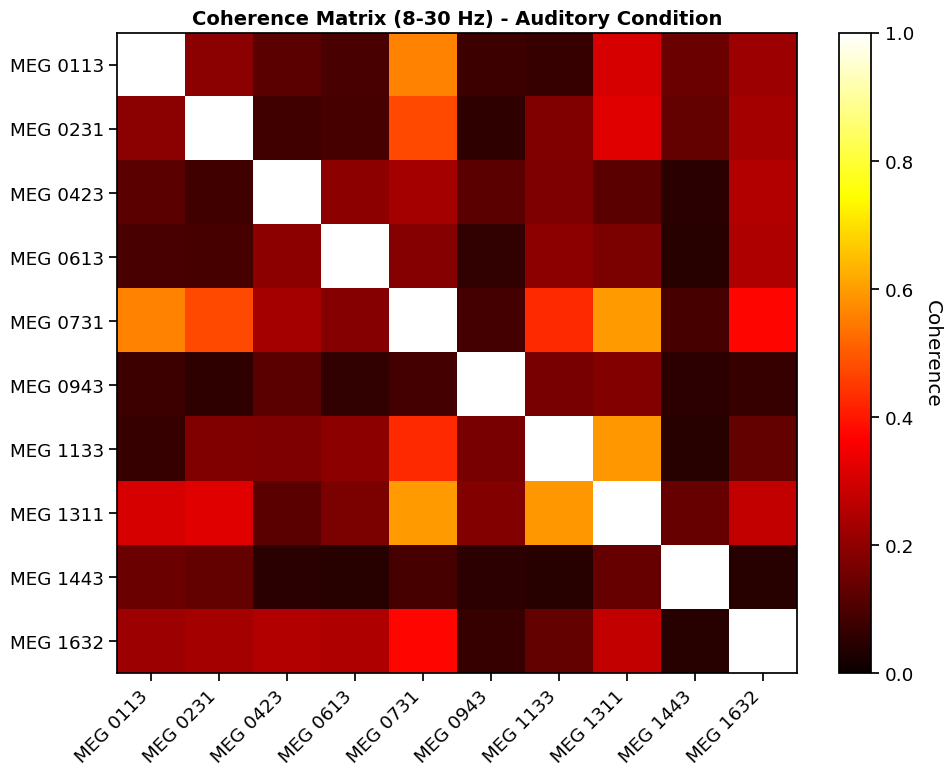

In [10]:
# Visualize coherence matrix
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(con_full_aud, cmap='hot', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(n_sensors))
ax.set_xticklabels([name[:10] for name in selected_ch_names], rotation=45, ha='right')
ax.set_yticks(range(n_sensors))
ax.set_yticklabels([name[:10] for name in selected_ch_names])
ax.set_title('Coherence Matrix (8-30 Hz) - Auditory Condition', fontsize=14, fontweight='bold')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Coherence', rotation=270, labelpad=20)

plt.tight_layout()
plt.show()

### 3.2. Imaginary Coherence

**Imaginary coherence** uses only the imaginary part of coherency, which:
- Eliminates zero-lag (instantaneous) connections
- Reduces volume conduction artifacts
- More conservative but more specific

**When to use:**
- Sensor-space analysis
- When volume conduction is a concern
- When you want to be confident connections are real

In [11]:
# Compute imaginary coherence
con_imcoh_aud = spectral_connectivity_epochs(
    epochs_auditory,
    method='imcoh',  # Imaginary coherence
    mode='multitaper',
    sfreq=epochs.info['sfreq'],
    fmin=fmin,
    fmax=fmax,
    faverage=True,
    indices=indices,  # Same sensor pairs as before
    n_jobs=1
)

# Extract and reconstruct matrix
con_data_imcoh = con_imcoh_aud.get_data()[:, 0]
con_full_imcoh = np.zeros((n_sensors, n_sensors))

# Fill in the connectivity values
for idx, (i, j) in enumerate(pairs):
    con_full_imcoh[i, j] = con_data_imcoh[idx]
    con_full_imcoh[j, i] = con_data_imcoh[idx]

# Note: imaginary coherence diagonal is typically 0 (no imaginary part with self)
print(f"Mean imaginary coherence: {np.mean(np.abs(con_full_imcoh[np.triu_indices(n_sensors, k=1)])):.3f}")

Replacing existing metadata with 3 columns
Connectivity computation...
    computing connectivity for 45 connections
    using t=-0.200s..0.499s for estimation (421 points)
    frequencies: 8.6Hz..30.0Hz (16 points)
    connectivity scores will be averaged for each band
    Using multitaper spectrum estimation with 7 DPSS windows
    the following metrics will be computed: Imaginary Coherence
    computing cross-spectral density for epoch 1
    computing cross-spectral density for epoch 2
    computing cross-spectral density for epoch 3
    computing cross-spectral density for epoch 4
    computing cross-spectral density for epoch 5
    computing cross-spectral density for epoch 6
    computing cross-spectral density for epoch 7
    computing cross-spectral density for epoch 8
    computing cross-spectral density for epoch 9
    computing cross-spectral density for epoch 10
    computing cross-spectral density for epoch 11
    computing cross-spectral density for epoch 12
    computing

### 3.3. Phase Locking Value (PLV)

**Phase Locking Value (PLV)** measures the consistency of phase differences between two signals across trials.

**Mathematical Definition:**
$$
PLV = \left| \frac{1}{N} \sum_{n=1}^{N} e^{i(\phi_1(t_n) - \phi_2(t_n))} \right|
$$

Where:
- $\phi_1(t_n)$, $\phi_2(t_n)$ are the instantaneous phases of the two signals at time $t_n$
- $N$ is the number of time points or trials
- Range: [0, 1] (0 = no phase locking, 1 = perfect phase locking)

**Key characteristics:**
- Measures phase synchronization only (ignores amplitude)
- Sensitive to volume conduction (like coherence)
- Useful for detecting phase relationships across trials
- Best used in source space or with imaginary PLV

In [12]:
# Compute Phase Locking Value (PLV)
con_plv_aud = spectral_connectivity_epochs(
    epochs_auditory,
    method='plv',  # Phase Locking Value
    mode='multitaper',
    sfreq=epochs.info['sfreq'],
    fmin=fmin,
    fmax=fmax,
    faverage=True,
    indices=indices,  # Same sensor pairs as before
    n_jobs=1
)

# Extract and reconstruct matrix
con_data_plv = con_plv_aud.get_data()[:, 0]
con_full_plv = np.zeros((n_sensors, n_sensors))

# Fill in the connectivity values
for idx, (i, j) in enumerate(pairs):
    con_full_plv[i, j] = con_data_plv[idx]
    con_full_plv[j, i] = con_data_plv[idx]

print(f"Mean PLV: {np.mean(con_full_plv[np.triu_indices(n_sensors, k=1)]):.3f}")
print(f"Min PLV: {np.min(con_full_plv[np.triu_indices(n_sensors, k=1)]):.3f}")
print(f"Max PLV: {np.max(con_full_plv[np.triu_indices(n_sensors, k=1)]):.3f}")

Replacing existing metadata with 3 columns
Connectivity computation...
    computing connectivity for 45 connections
    using t=-0.200s..0.499s for estimation (421 points)
    frequencies: 8.6Hz..30.0Hz (16 points)
    connectivity scores will be averaged for each band
    Using multitaper spectrum estimation with 7 DPSS windows
    the following metrics will be computed: PLV
    computing cross-spectral density for epoch 1
    computing cross-spectral density for epoch 2
    computing cross-spectral density for epoch 3
    computing cross-spectral density for epoch 4
    computing cross-spectral density for epoch 5
    computing cross-spectral density for epoch 6
    computing cross-spectral density for epoch 7
    computing cross-spectral density for epoch 8
    computing cross-spectral density for epoch 9
    computing cross-spectral density for epoch 10
    computing cross-spectral density for epoch 11
    computing cross-spectral density for epoch 12
    computing cross-spectral 

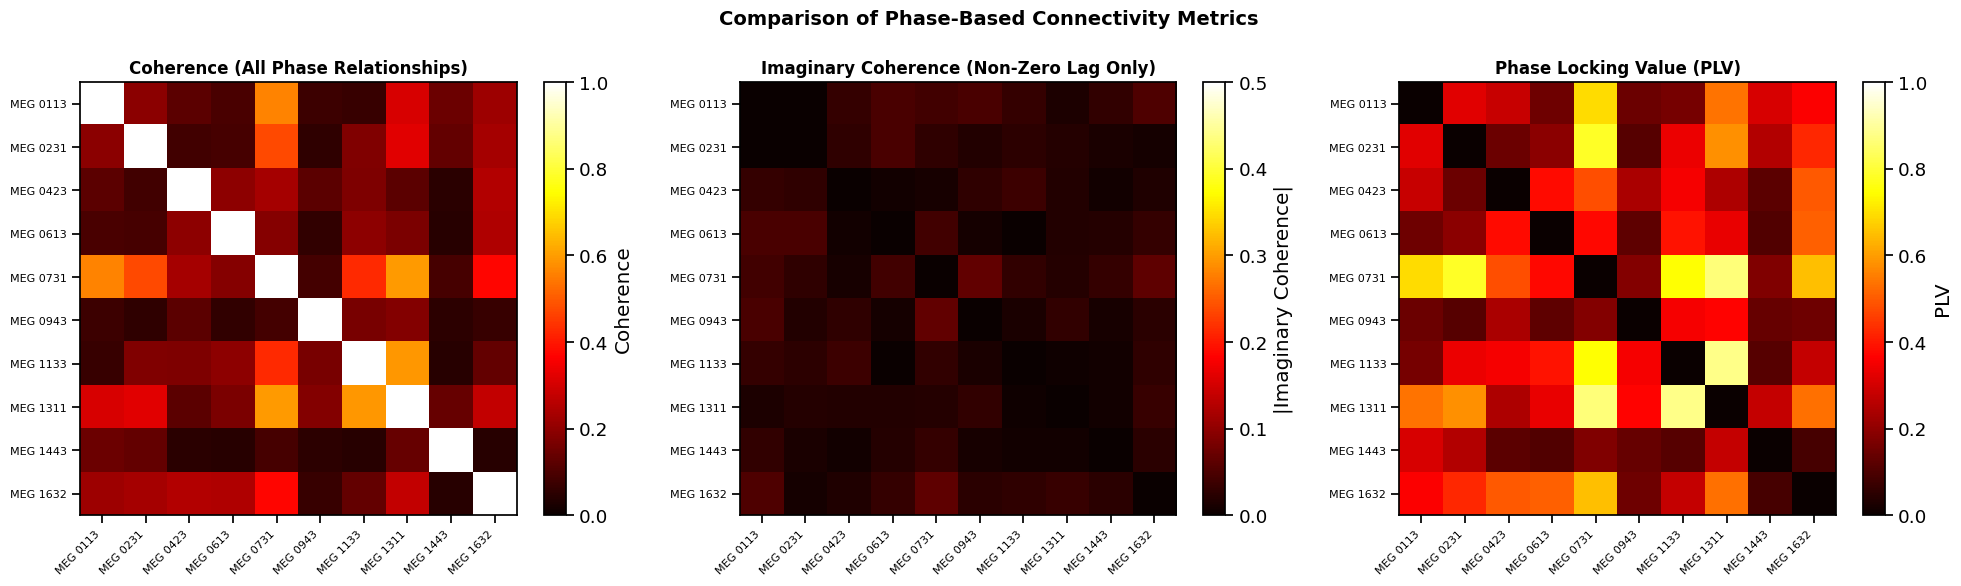


Comparison of connectivity metrics:
  Mean Coherence: 0.193
  Mean |Imaginary Coherence|: 0.025
  Mean PLV: 0.350

Note: Imaginary coherence values are typically lower because:
  - Removes instantaneous (zero-lag) connections
  - Reduces volume conduction artifacts
  - More conservative but more specific


In [13]:
# Compare coherence, imaginary coherence, and PLV
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Regular coherence
im1 = axes[0].imshow(con_full_aud, cmap='hot', vmin=0, vmax=1, aspect='auto')
axes[0].set_title('Coherence (All Phase Relationships)', fontsize=12, fontweight='bold')
axes[0].set_xticks(range(n_sensors))
axes[0].set_xticklabels([name[:10] for name in selected_ch_names], rotation=45, ha='right', fontsize=8)
axes[0].set_yticks(range(n_sensors))
axes[0].set_yticklabels([name[:10] for name in selected_ch_names], fontsize=8)
plt.colorbar(im1, ax=axes[0], label='Coherence')

# Imaginary coherence
im2 = axes[1].imshow(np.abs(con_full_imcoh), cmap='hot', vmin=0, vmax=0.5, aspect='auto')
axes[1].set_title('Imaginary Coherence (Non-Zero Lag Only)', fontsize=12, fontweight='bold')
axes[1].set_xticks(range(n_sensors))
axes[1].set_xticklabels([name[:10] for name in selected_ch_names], rotation=45, ha='right', fontsize=8)
axes[1].set_yticks(range(n_sensors))
axes[1].set_yticklabels([name[:10] for name in selected_ch_names], fontsize=8)
plt.colorbar(im2, ax=axes[1], label='|Imaginary Coherence|')

# Phase Locking Value
im3 = axes[2].imshow(con_full_plv, cmap='hot', vmin=0, vmax=1, aspect='auto')
axes[2].set_title('Phase Locking Value (PLV)', fontsize=12, fontweight='bold')
axes[2].set_xticks(range(n_sensors))
axes[2].set_xticklabels([name[:10] for name in selected_ch_names], rotation=45, ha='right', fontsize=8)
axes[2].set_yticks(range(n_sensors))
axes[2].set_yticklabels([name[:10] for name in selected_ch_names], fontsize=8)
plt.colorbar(im3, ax=axes[2], label='PLV')

plt.suptitle('Comparison of Phase-Based Connectivity Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nComparison of connectivity metrics:")
print(f"  Mean Coherence: {np.mean(con_full_aud[np.triu_indices(n_sensors, k=1)]):.3f}")
print(f"  Mean |Imaginary Coherence|: {np.mean(np.abs(con_full_imcoh[np.triu_indices(n_sensors, k=1)])):.3f}")
print(f"  Mean PLV: {np.mean(con_full_plv[np.triu_indices(n_sensors, k=1)]):.3f}")
print("\nNote: Imaginary coherence values are typically lower because:")
print("  - Removes instantaneous (zero-lag) connections")
print("  - Reduces volume conduction artifacts")
print("  - More conservative but more specific")

### 3.4. Frequency-Specific Connectivity

Brain oscillations at different frequencies serve different functions:

| Band | Frequency | Typical Role |
|------|-----------|-------------|
| **Delta** | 1-4 Hz | Deep sleep, attention |
| **Theta** | 4-8 Hz | Memory, navigation |
| **Alpha** | 8-13 Hz | Relaxation, inhibition |
| **Beta** | 13-30 Hz | Motor control, attention |
| **Gamma** | 30-100 Hz | Sensory processing, binding |

In [14]:
# Compute connectivity for different frequency bands
freq_bands = {
    'Theta': (4, 8),
    'Alpha': (8, 13),
    'Beta': (13, 30)
}

# Pick a pair of sensors to analyze
sensor_pair_idx = (0, 4)  # Indices within our sensor_indices list
sensor_1_global = sensor_indices[sensor_pair_idx[0]]
sensor_2_global = sensor_indices[sensor_pair_idx[1]]

print(f"Analyzing connectivity between:")
print(f"  Sensor 1: {epochs.ch_names[sensor_1_global]} (index {sensor_1_global})")
print(f"  Sensor 2: {epochs.ch_names[sensor_2_global]} (index {sensor_2_global})")

Analyzing connectivity between:
  Sensor 1: MEG 0113 (index 0)
  Sensor 2: MEG 0731 (index 80)


In [15]:
# Compute coherence across frequencies for the selected pair
con_freq = spectral_connectivity_epochs(
    epochs_auditory,
    method='coh',
    mode='multitaper',
    sfreq=epochs.info['sfreq'],
    fmin=1.,
    fmax=40.,
    faverage=False,  # Keep frequency resolution
    indices=([sensor_1_global], [sensor_2_global]),  # Just this one pair
    n_jobs=1
)

# Get frequency axis and connectivity values
freqs = con_freq.freqs
coh_values = con_freq.get_data()[0, :]  # First (and only) connection pair

print(f"Computed coherence from {freqs[0]:.1f} to {freqs[-1]:.1f} Hz")
print(f"Number of frequency points: {len(freqs)}")

Replacing existing metadata with 3 columns
Connectivity computation...
    computing connectivity for 1 connections
    using t=-0.200s..0.499s for estimation (421 points)
    frequencies: 1.4Hz..39.9Hz (28 points)
    Using multitaper spectrum estimation with 7 DPSS windows
    the following metrics will be computed: Coherence
    computing cross-spectral density for epoch 1
    computing cross-spectral density for epoch 2
    computing cross-spectral density for epoch 3
    computing cross-spectral density for epoch 4
    computing cross-spectral density for epoch 5
    computing cross-spectral density for epoch 6
    computing cross-spectral density for epoch 7
    computing cross-spectral density for epoch 8
    computing cross-spectral density for epoch 9
    computing cross-spectral density for epoch 10
    computing cross-spectral density for epoch 11
    computing cross-spectral density for epoch 12
    computing cross-spectral density for epoch 13
    computing cross-spectral 

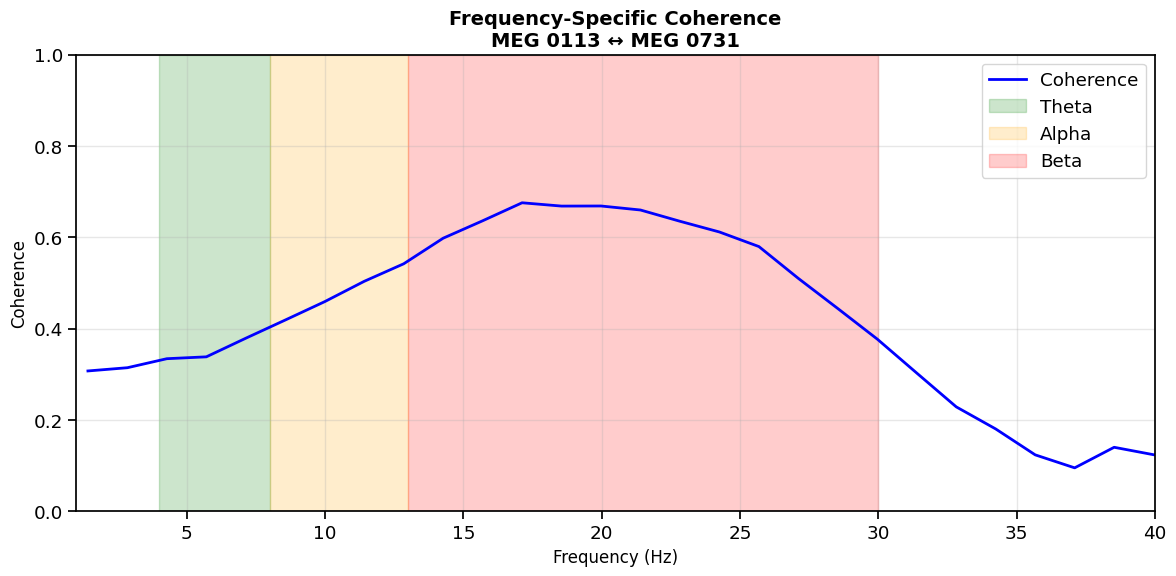

In [16]:
# Visualize frequency-specific coherence
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(freqs, coh_values, 'b-', linewidth=2, label='Coherence')

# Shade frequency bands
colors = {'Theta': 'green', 'Alpha': 'orange', 'Beta': 'red'}
for band_name, (fmin_band, fmax_band) in freq_bands.items():
    ax.axvspan(fmin_band, fmax_band, alpha=0.2, color=colors[band_name], label=band_name)

ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Coherence', fontsize=12)
ax.set_title(f'Frequency-Specific Coherence\n{epochs.ch_names[sensor_1_global]} ↔ {epochs.ch_names[sensor_2_global]}',fontsize=14, fontweight='bold')
ax.set_xlim([1, 40])
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [17]:
print("\nPeak coherence by band:")
freqs = np.array(freqs)
for band_name, (fmin_band, fmax_band) in freq_bands.items():
    mask = (freqs >= fmin_band) & (freqs <= fmax_band)
    if np.sum(mask) > 0:
        peak_freq = freqs[mask][np.argmax(coh_values[mask])]
        peak_coh = np.max(coh_values[mask])
        print(f"  {band_name:6s}: {peak_coh:.3f} at {peak_freq:.1f} Hz")


Peak coherence by band:
  Theta : 0.379 at 7.1 Hz
  Alpha : 0.542 at 12.8 Hz
  Beta  : 0.675 at 17.1 Hz


## 4. Source-Space Connectivity

### Why Source Space?

**Advantages:**
- Better spatial specificity
- Reduced volume conduction
- Anatomically interpretable
- Can use ROI-based analysis

**Approach:**
1. Compute inverse solution (source reconstruction)
2. Extract ROI time courses
3. Compute connectivity between ROIs

### 4.1. Prepare Inverse Operator

In [18]:
# Load forward solution and noise covariance
fwd_fname = data_path / 'MEG' / 'sample' / 'sample_audvis-meg-eeg-oct-6-fwd.fif'
cov_fname = data_path / 'MEG' / 'sample' / 'sample_audvis-cov.fif'

fwd = mne.read_forward_solution(fwd_fname)
noise_cov = mne.read_cov(cov_fname)

# Create inverse operator
inverse_operator = make_inverse_operator(
    epochs.info, fwd, noise_cov,
    loose=0.2, depth=0.8
)

print("Prepared inverse operator")

Reading forward solution from /Users/yibeisita/Documents/neuro-ai-playground/datasets/meg_sample/MNE-sample-data/MEG/sample/sample_audvis-meg-eeg-oct-6-fwd.fif...
    Reading a source space...
    Computing patch statistics...
    Patch information added...
    Distance information added...
    [done]
    Reading a source space...
    Computing patch statistics...
    Patch information added...
    Distance information added...
    [done]
    2 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (7498 sources, 306 channels, free orientations)
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read EEG forward solution (7498 sources, 60 channels, free orientations)
    Forward solutions combined: MEG, EEG
    Source spaces transformed to the forward solution coordinate frame
    366 x 366 full covariance (kind = 1) found.
    Read a total of 4 projection items:
     

### 4.2. Extract ROI Labels

In [19]:
# Read parcellation labels
labels = mne.read_labels_from_annot(
    'sample', parc='aparc',
    subjects_dir=subjects_dir
)

print(f"Loaded {len(labels)} cortical labels")

# Select specific ROIs for connectivity analysis
roi_names = [
    'superiortemporal-lh',  # Auditory cortex (left)
    'superiortemporal-rh',  # Auditory cortex (right)
    'lateraloccipital-lh',  # Visual cortex (left)
    'lateraloccipital-rh',  # Visual cortex (right)
    'supramarginal-lh',     # Parietal (left)
    'supramarginal-rh'      # Parietal (right)
]

# Find corresponding labels
selected_labels = []
for roi_name in roi_names:
    label = [l for l in labels if roi_name in l.name]
    if label:
        selected_labels.append(label[0])

print(f"\nSelected {len(selected_labels)} ROIs for analysis:")
for label in selected_labels:
    print(f"  - {label.name}: {len(label.vertices)} vertices")

Reading labels from parcellation...
   read 34 labels from /Users/yibeisita/Documents/neuro-ai-playground/datasets/meg_sample/MNE-sample-data/subjects/sample/label/lh.aparc.annot
   read 34 labels from /Users/yibeisita/Documents/neuro-ai-playground/datasets/meg_sample/MNE-sample-data/subjects/sample/label/rh.aparc.annot
Loaded 68 cortical labels

Selected 6 ROIs for analysis:
  - superiortemporal-lh: 5433 vertices
  - superiortemporal-rh: 5404 vertices
  - lateraloccipital-lh: 7446 vertices
  - lateraloccipital-rh: 7995 vertices
  - supramarginal-lh: 6100 vertices
  - supramarginal-rh: 5872 vertices


### 4.3. Compute Source-Space Connectivity

In [20]:
# Apply inverse operator to get source time courses
snr = 3.0
lambda2 = 1.0 / snr ** 2
method = "dSPM"

stcs_auditory = apply_inverse_epochs(
    epochs_auditory, inverse_operator, lambda2, method,
    pick_ori="normal", return_generator=False
)

stcs_visual = apply_inverse_epochs(
    epochs_visual, inverse_operator, lambda2, method,
    pick_ori="normal", return_generator=False
)

print(f"Computed source estimates for {len(stcs_auditory)} auditory epochs")
print(f"Computed source estimates for {len(stcs_visual)} visual epochs")

Preparing the inverse operator for use...
    Scaled noise and source covariance from nave = 1 to nave = 1
    Created the regularized inverter
    Created an SSP operator (subspace dimension = 3)
    Created the whitener using a noise covariance matrix with rank 302 (3 small eigenvalues omitted)
    Computing noise-normalization factors (dSPM)...
[done]
Picked 305 channels from the data
Computing inverse...
    Eigenleads need to be weighted ...
Processing epoch : 1 / 143
Processing epoch : 2 / 143
Processing epoch : 3 / 143
Processing epoch : 4 / 143
Processing epoch : 5 / 143
Processing epoch : 6 / 143
Processing epoch : 7 / 143
Processing epoch : 8 / 143
Processing epoch : 9 / 143
Processing epoch : 10 / 143
Processing epoch : 11 / 143
Processing epoch : 12 / 143
Processing epoch : 13 / 143
Processing epoch : 14 / 143
Processing epoch : 15 / 143
Processing epoch : 16 / 143
Processing epoch : 17 / 143
Processing epoch : 18 / 143
Processing epoch : 19 / 143
Processing epoch : 20 / 14

In [21]:
# Extract label time courses
def extract_label_time_courses(stcs, labels, mode='mean'):
    """
    Extract time courses for each label from source estimates.
    """
    n_epochs = len(stcs)
    n_labels = len(labels)
    n_times = stcs[0].data.shape[1]
    
    label_ts = np.zeros((n_epochs, n_labels, n_times))
    
    for epoch_idx, stc in enumerate(stcs):
        for label_idx, label in enumerate(labels):
            # Extract data for this label
            label_data = stc.extract_label_time_course(label, inverse_operator['src'], mode=mode)
            label_ts[epoch_idx, label_idx, :] = label_data.flatten()
    
    return label_ts

In [22]:
# Extract time courses
print("Extracting ROI time courses...")
label_ts_aud = extract_label_time_courses(stcs_auditory, selected_labels, mode='mean')
label_ts_vis = extract_label_time_courses(stcs_visual, selected_labels, mode='mean')

print(f"Auditory label time courses shape: {label_ts_aud.shape}")
print(f"Visual label time courses shape: {label_ts_vis.shape}")

Extracting ROI time courses...
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time cou

In [23]:
# Compute envelope correlation
env_corr_aud = envelope_correlation(
    label_ts_aud,
    orthogonalize='pairwise'  # Remove zero-lag correlation
)

env_corr_vis = envelope_correlation(
    label_ts_vis,
    orthogonalize='pairwise'
)

# Extract the correlation matrices
env_corr_aud_matrix = env_corr_aud.get_data()
env_corr_vis_matrix = env_corr_vis.get_data()

# Handle different array dimensions
# Shape can be (n_epochs, n_labels, n_labels, n_freqs) or (n_labels, n_labels, n_freqs)
if env_corr_aud_matrix.ndim == 4:
    # Average across epochs and take first frequency bin
    env_corr_aud_matrix = np.mean(env_corr_aud_matrix[:, :, :, 0], axis=0)
elif env_corr_aud_matrix.ndim == 3:
    # Take first frequency bin if present
    env_corr_aud_matrix = env_corr_aud_matrix[:, :, 0]

if env_corr_vis_matrix.ndim == 4:
    # Average across epochs and take first frequency bin
    env_corr_vis_matrix = np.mean(env_corr_vis_matrix[:, :, :, 0], axis=0)
elif env_corr_vis_matrix.ndim == 3:
    # Take first frequency bin if present
    env_corr_vis_matrix = env_corr_vis_matrix[:, :, 0]

print(f"Envelope correlation shape: {env_corr_aud_matrix.shape}")
print(f"Mean envelope correlation (auditory): {np.mean(np.abs(env_corr_aud_matrix)):.3f}")
print(f"Mean envelope correlation (visual): {np.mean(np.abs(env_corr_vis_matrix)):.3f}")

Envelope correlation shape: (6, 6)
Mean envelope correlation (auditory): 0.095
Mean envelope correlation (visual): 0.091


## 5. Graph Theory Analysis

### Network Metrics

Once we have a connectivity matrix, we can treat the brain as a **network** or **graph**:
- **Nodes**: Brain regions (ROIs)
- **Edges**: Connections (correlations, coherence, etc.)

Key metrics:
- **Degree**: Number of connections to a node
- **Strength**: Sum of connection weights
- **Betweenness Centrality**: How often a node lies on shortest paths
- **Clustering Coefficient**: How interconnected a node's neighbors are
- **Hub nodes**: Highly connected nodes that integrate information

In [24]:
# Threshold connectivity matrix to create binary network
# Keep top 30% of connections
threshold_percentile = 70  # Keep connections above 70th percentile

# Get upper triangle (no diagonal)
triu_indices = np.triu_indices(len(selected_labels), k=1)
env_values_aud = np.abs(env_corr_aud_matrix[triu_indices])

# Determine threshold
threshold = np.percentile(env_values_aud, threshold_percentile)
print(f"Connection threshold: {threshold:.3f}")

# Create binary adjacency matrix
adj_matrix = (np.abs(env_corr_aud_matrix) > threshold).astype(int)
np.fill_diagonal(adj_matrix, 0)  # No self-connections

print(f"Network density: {np.sum(adj_matrix) / (len(selected_labels) * (len(selected_labels) - 1)):.3f}")
print(f"Total connections: {np.sum(adj_matrix) // 2}")

Connection threshold: 0.118
Network density: 0.333
Total connections: 5


In [25]:
# Create NetworkX graph
G = nx.from_numpy_array(adj_matrix)

# Compute network metrics
degree = dict(G.degree())
betweenness = nx.betweenness_centrality(G)
clustering = nx.clustering(G)

# Create summary DataFrame
network_metrics = pd.DataFrame({
    'ROI': [l.name.split('-')[0] for l in selected_labels],
    'Degree': [degree[i] for i in range(len(selected_labels))],
    'Betweenness': [betweenness[i] for i in range(len(selected_labels))],
    'Clustering': [clustering[i] for i in range(len(selected_labels))]
})

# Sort by degree
network_metrics = network_metrics.sort_values('Degree', ascending=False)

print("\nNetwork Metrics (sorted by degree):")
print(network_metrics.to_string(index=False))


Network Metrics (sorted by degree):
             ROI  Degree  Betweenness  Clustering
   supramarginal       4          0.5    0.166667
superiortemporal       2          0.0    1.000000
   supramarginal       2          0.0    1.000000
superiortemporal       1          0.0    0.000000
lateraloccipital       1          0.0    0.000000
lateraloccipital       0          0.0    0.000000


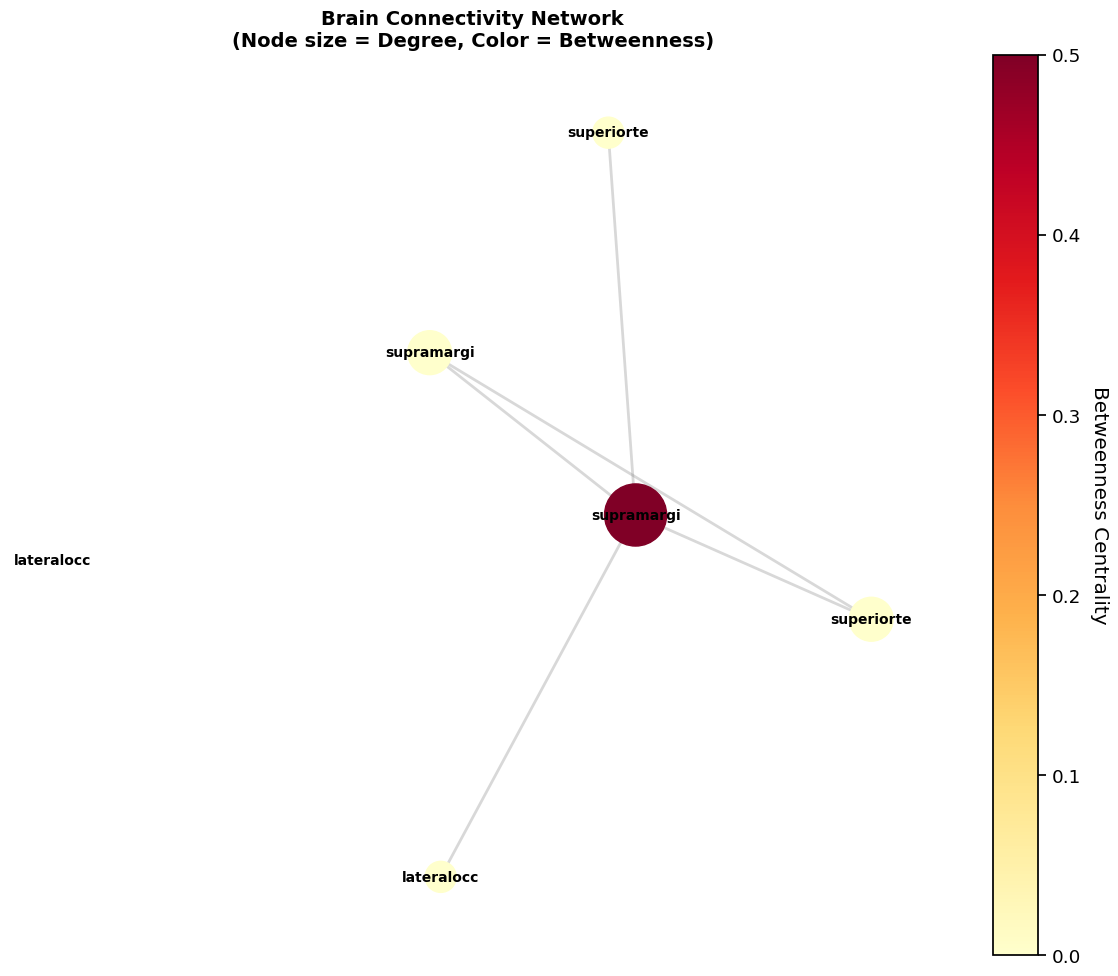

In [26]:
# Visualize network graph
fig, ax = plt.subplots(figsize=(12, 10))

pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

# Node sizes based on degree
node_sizes = [degree[i] * 500 for i in range(len(selected_labels))]
# Node colors based on betweenness centrality
node_colors = [betweenness[i] for i in range(len(selected_labels))]

nodes = nx.draw_networkx_nodes(
    G, pos, node_size=node_sizes, node_color=node_colors,
    cmap='YlOrRd', vmin=0, vmax=max(node_colors),
    ax=ax
)

nx.draw_networkx_edges(
    G, pos, alpha=0.3, width=2, edge_color='gray', ax=ax
)

labels_dict = {i: l.name.split('-')[0][:10] for i, l in enumerate(selected_labels)}
nx.draw_networkx_labels(
    G, pos, labels_dict, font_size=10, font_weight='bold', ax=ax
)

sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=plt.Normalize(vmin=0, vmax=max(node_colors)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Betweenness Centrality', rotation=270, labelpad=20)

ax.set_title('Brain Connectivity Network\n(Node size = Degree, Color = Betweenness)', fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()

In [27]:
# Identify hub nodes
print("\nHub Regions (Degree ≥ median + 1 SD):")
degree_values = list(degree.values())
hub_threshold = np.mean(degree_values) + np.std(degree_values)
for i, deg in degree.items():
    if deg >= hub_threshold:
        print(f"  {selected_labels[i].name}: Degree = {deg}")


Hub Regions (Degree ≥ median + 1 SD):
  supramarginal-lh: Degree = 4


## 6. Condition Comparison

### 6.1. Statistical Comparison of Connectivity

In [28]:
# Compare connectivity strength between conditions
# Focus on specific ROI pairs

# Find auditory cortex indices
aud_left_idx = [i for i, l in enumerate(selected_labels) if 'superiortemporal-lh' in l.name][0]
aud_right_idx = [i for i, l in enumerate(selected_labels) if 'superiortemporal-rh' in l.name][0]

# Find visual cortex indices
vis_left_idx = [i for i, l in enumerate(selected_labels) if 'lateraloccipital-lh' in l.name][0]
vis_right_idx = [i for i, l in enumerate(selected_labels) if 'lateraloccipital-rh' in l.name][0]

print("ROI Indices:")
print(f"  Auditory Left: {aud_left_idx} ({selected_labels[aud_left_idx].name})")
print(f"  Auditory Right: {aud_right_idx} ({selected_labels[aud_right_idx].name})")
print(f"  Visual Left: {vis_left_idx} ({selected_labels[vis_left_idx].name})")
print(f"  Visual Right: {vis_right_idx} ({selected_labels[vis_right_idx].name})")

ROI Indices:
  Auditory Left: 0 (superiortemporal-lh)
  Auditory Right: 1 (superiortemporal-rh)
  Visual Left: 2 (lateraloccipital-lh)
  Visual Right: 3 (lateraloccipital-rh)


In [29]:
# Extract connectivity for key connections
connections = {
    'Auditory L-R': (aud_left_idx, aud_right_idx),
    'Visual L-R': (vis_left_idx, vis_right_idx),
    'Aud L - Vis L': (aud_left_idx, vis_left_idx),
    'Aud R - Vis R': (aud_right_idx, vis_right_idx)
}

# Compare conditions
comparison_data = []

for conn_name, (i, j) in connections.items():
    conn_aud = env_corr_aud_matrix[i, j]
    conn_vis = env_corr_vis_matrix[i, j]
    
    comparison_data.append({
        'Connection': conn_name,
        'Auditory': conn_aud,
        'Visual': conn_vis,
        'Difference': conn_aud - conn_vis
    })

comparison_df = pd.DataFrame(comparison_data)
print("\nConnectivity Comparison:")
print(comparison_df.to_string(index=False))


Connectivity Comparison:
   Connection  Auditory   Visual  Difference
 Auditory L-R  0.112248 0.114321   -0.002073
   Visual L-R  0.106169 0.112319   -0.006150
Aud L - Vis L  0.105857 0.114668   -0.008812
Aud R - Vis R  0.100288 0.107406   -0.007118


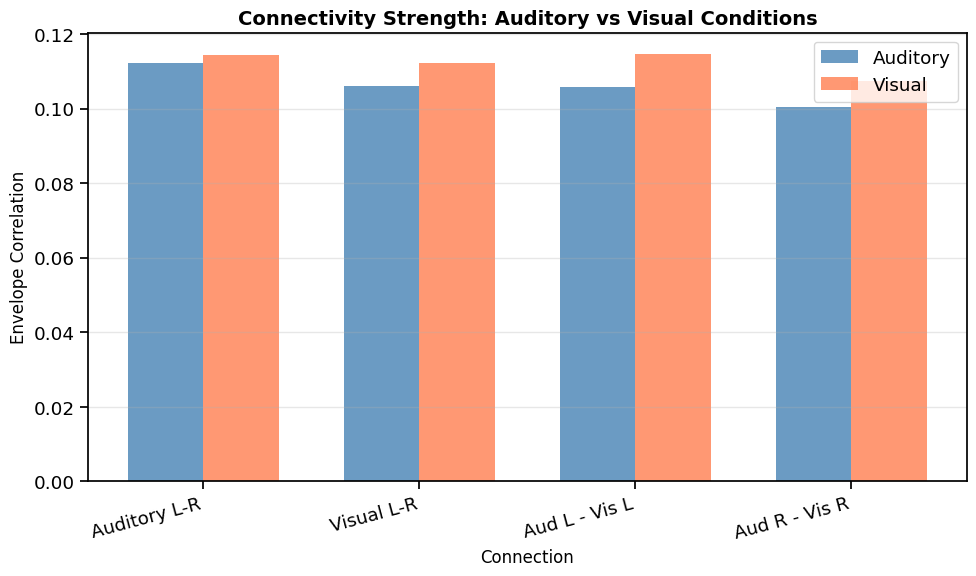

In [30]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(connections))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['Auditory'], width, label='Auditory', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, comparison_df['Visual'], width, label='Visual', color='coral', alpha=0.8)

ax.set_xlabel('Connection', fontsize=12)
ax.set_ylabel('Envelope Correlation', fontsize=12)
ax.set_title('Connectivity Strength: Auditory vs Visual Conditions', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Connection'], rotation=15, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

### 6.2. Network Comparison

In [31]:
# Compute network metrics for both conditions
def compute_network_metrics(conn_matrix, threshold_percentile=70):
    """
    Compute graph theory metrics from connectivity matrix.
    """
    # Threshold
    triu_indices = np.triu_indices(conn_matrix.shape[0], k=1)
    conn_values = np.abs(conn_matrix[triu_indices])
    threshold = np.percentile(conn_values, threshold_percentile)
    
    # Binary adjacency
    adj = (np.abs(conn_matrix) > threshold).astype(int)
    np.fill_diagonal(adj, 0)
    
    G = nx.from_numpy_array(adj)
    
    metrics = {
        'density': nx.density(G),
        'avg_degree': np.mean(list(dict(G.degree()).values())),
        'avg_clustering': nx.average_clustering(G),
        'global_efficiency': nx.global_efficiency(G)
    }
    
    return metrics, G

# Compute for both conditions
metrics_aud, G_aud = compute_network_metrics(env_corr_aud_matrix)
metrics_vis, G_vis = compute_network_metrics(env_corr_vis_matrix)

print("Network Metrics Comparison:")
print("\nAuditory Condition:")
for key, value in metrics_aud.items():
    print(f"  {key:20s}: {value:.3f}")

print("\nVisual Condition:")
for key, value in metrics_vis.items():
    print(f"  {key:20s}: {value:.3f}")

print("\nDifferences (Auditory - Visual):")
for key in metrics_aud.keys():
    diff = metrics_aud[key] - metrics_vis[key]
    print(f"  {key:20s}: {diff:+.3f}")

Network Metrics Comparison:

Auditory Condition:
  density             : 0.333
  avg_degree          : 1.667
  avg_clustering      : 0.361
  global_efficiency   : 0.500

Visual Condition:
  density             : 0.333
  avg_degree          : 1.667
  avg_clustering      : 0.000
  global_efficiency   : 0.600

Differences (Auditory - Visual):
  density             : +0.000
  avg_degree          : +0.000
  avg_clustering      : +0.361
  global_efficiency   : -0.100


## Summary and Key Takeaways

### What We Learned

1. **Connectivity Fundamentals:**
   - **Functional connectivity**: Statistical dependencies between brain regions
   - **Volume conduction**: Major challenge in EEG/MEG connectivity
   - **Solutions**: Source space, imaginary coherence, orthogonalization

2. **Connectivity Metrics:**
   - **Coherence**: Frequency-domain correlation (phase + amplitude)
   - **Imaginary Coherence**: Reduces volume conduction (non-zero lag only)
   - **PLV**: Phase synchronization measure
   - **Envelope Correlation**: Slow amplitude coupling
   - Each metric captures different aspects of connectivity

3. **Sensor vs Source Space:**
   - **Sensor space**: Easier but affected by volume conduction
   - **Source space**: More specific, anatomically interpretable
   - **ROI-based**: Reduces dimensionality, enables network analysis

4. **Frequency Specificity:**
   - Different frequency bands → different functions
   - **Theta** (4-8 Hz): Memory, navigation
   - **Alpha** (8-13 Hz): Inhibition, attention
   - **Beta** (13-30 Hz): Motor control
   - **Gamma** (30-100 Hz): Sensory processing

5. **Graph Theory:**
   - Brain as network: ROIs = nodes, connectivity = edges
   - **Hub regions**: Highly connected integration centers
   - **Network metrics**: Degree, betweenness, clustering
   - **Condition differences**: Networks reconfigure with task

### Best Practices

**General Guidelines:**
- Always consider volume conduction in sensor space
- Use source space when possible for connectivity
- Choose appropriate metric for research question
- Threshold connectivity matrices carefully
- Validate with multiple metrics when possible

**Statistical Considerations:**
- Multiple comparisons: Bonferroni, FDR, cluster-based permutation
- Baseline correction for time-resolved analyses
- Adequate number of trials for stable estimates
- Cross-validation for machine learning approaches

**Interpretation:**
- Connectivity ≠ causality (except for directed measures)
- Context matters: task, state, frequency
- Compare with anatomical connectivity when available
- Consider physiological plausibility